In [4]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r'C:\Users\user\my_snippet\DataSets\coffee_shop.csv',encoding='UTF-8')
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,01-01-2023,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,01-01-2023,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,01-01-2023,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,01-01-2023,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,01-01-2023,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [5]:
#data clean
len(df['transaction_id']),df['transaction_id'].nunique()
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [6]:
#essential measure
df['datetime'] = pd.to_datetime(df['transaction_date']+' ' +df['transaction_time'],format='%d-%m-%Y %H:%M:%S')
df['revenue'] = df['unit_price']*df['transaction_qty']

In [7]:
#monthly revenue
df.resample('ME',on='datetime')['revenue'].sum()#.plot(kind= 'bar')

datetime
2023-01-31     81677.74
2023-02-28     76145.19
2023-03-31     98834.68
2023-04-30    118941.08
2023-05-31    156727.76
2023-06-30    166485.88
Freq: ME, Name: revenue, dtype: float64

In [8]:
#most revenue generator store
df.groupby('store_location')['revenue'].sum().idxmax()

"Hell's Kitchen"

store_location   hour
Astoria          10      5291
                 9       5083
                 8       4966
Hell's Kitchen   10      6957
                 8       6909
                 9       6767
Lower Manhattan  10      6297
                 9       5914
                 7       5792
Name: count, dtype: int64

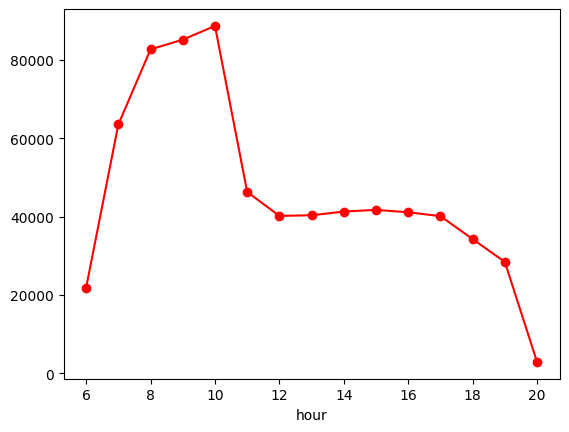

In [ ]:
df['hour'] = df['datetime'].dt.hour
#hourwise revenue
df.groupby('hour')['revenue'].sum().plot(color='red',marker='o')
#top-hour
df.groupby('store_location')['hour'].value_counts().groupby(level=0).head(3)